In [10]:
# =============================================================
# 실습 4 · LSTM & GRU 분류 비교
# Google Colab Version
# =============================================================
# 목표: 실습 3(SimpleRNN)을 LSTM / GRU 로 교체하여
#       장기 의존성 처리 효과를 정확도 + t-SNE로 비교한다.
# =============================================================

# -------------------------------------------------------------
# 0. 패키지 설치 — Colab 최초 실행 시 이 셀만 먼저 실행
# -------------------------------------------------------------
# !pip install -q koreanize-matplotlib

# -------------------------------------------------------------
# 1. Setup
# -------------------------------------------------------------
import io
import os
import requests
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import koreanize_matplotlib
try:
    from IPython import display as ipy_display
except ImportError:
    ipy_display = None

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [12]:
# =============================================================
# Part A · 데이터 로드 + 분할
# =============================================================

url = "https://raw.githubusercontent.com/hongsukyi/Lectures/main/data/aihub_3class_n2400.npz"

print("데이터 다운로드 중...")
response = requests.get(url)
response.raise_for_status()
data = np.load(io.BytesIO(response.content), allow_pickle=True)
print("다운로드 완료")
print("-" * 60)

X = data["input_ids"]
y = data["labels"]

VOCAB_SIZE  = int(data["vocab_size"])
MAX_LEN     = int(data["max_len"])
PAD_ID      = int(data["pad_id"])
NUM_CLASSES = int(data["num_classes"])
class_names = data["class_names"].tolist()

print(f"VOCAB: {VOCAB_SIZE:,}, MAX_LEN: {MAX_LEN}, PAD_ID: {PAD_ID}")
print(f"Classes: {class_names}")
print("-" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("-" * 60)

데이터 다운로드 중...
다운로드 완료
------------------------------------------------------------
VOCAB: 32,000, MAX_LEN: 32, PAD_ID: 0
Classes: ['면접', '학교', '협상']
------------------------------------------------------------
Train: (1920, 32), Test: (480, 32)
------------------------------------------------------------


In [13]:
# =============================================================
# Part B · 모델 구성
# =============================================================
# 실습 3 대비 변경:
#   SimpleRNN(128) --> LSTM(128) 또는 GRU(128)

EMBEDDING_DIM = 64

def build_lstm():
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="embedding"
        ),
        layers.LSTM(128, name="lstm"),   # 장기 의존성: cell state + hidden state
        layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_gru():
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True,
            name="embedding"
        ),
        layers.GRU(128, name="gru"),     # LSTM 경량화: reset gate + update gate
        layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [14]:
# =============================================================
# Part C · 실시간 Loss 콜백
# =============================================================

class LiveLossCallback(tf.keras.callbacks.Callback):
    """학습 중 Loss 실시간 시각화 (Colab / Jupyter 환경)"""

    def __init__(self, model_name="Model"):
        super().__init__()
        self.model_name = model_name

    def on_train_begin(self, logs=None):
        self.train_loss, self.val_loss = [], []
        self.fig, self.ax = plt.subplots(figsize=(8, 4))
        plt.ion()

    def on_epoch_end(self, epoch, logs=None):
        self.train_loss.append(logs.get("loss"))
        vl = logs.get("val_loss")
        has_val = vl is not None
        if has_val:
            self.val_loss.append(vl)
        epochs = range(1, epoch + 2)

        self.ax.clear()
        self.ax.plot(epochs, self.train_loss, "o-",  label="Train Loss")
        if has_val:
            self.ax.plot(epochs, self.val_loss, "s--", label="Val Loss")
        self.ax.set_xlabel("Epoch")
        self.ax.set_ylabel("Loss")
        self.ax.set_title(f"{self.model_name} — Loss (Live)")
        self.ax.legend()
        self.ax.grid(True, alpha=0.3)

        self.fig.canvas.draw()
        self.fig.canvas.flush_events()

        if ipy_display:
            ipy_display.clear_output(wait=True)
            ipy_display.display(self.fig)
        else:
            plt.pause(0.3)

    def on_train_end(self, logs=None):
        plt.ioff()
        plt.close(self.fig)

In [15]:
# =============================================================
# Part D · 문장 벡터 추출 함수 + t-SNE 시각화 함수
# =============================================================

def extract_sentence_vectors(model, X_data, layer_name):
    """지정 레이어 출력을 문장 벡터로 추출"""
    emb_layer = model.get_layer("embedding")
    rnn_layer = model.get_layer(layer_name)
    inp = layers.Input(shape=(MAX_LEN,))
    x   = emb_layer(inp)
    x   = rnn_layer(x)
    extractor = keras.Model(inputs=inp, outputs=x)
    return extractor.predict(X_data, batch_size=256, verbose=0)

In [16]:
def plot_tsne(vectors, labels, class_names, title, save_path=None):
    """t-SNE 2D 시각화"""
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        max_iter=1000,
        learning_rate="auto",
        init="pca",
        random_state=SEED
    )
    emb_2d = tsne.fit_transform(vectors)
    colors = ["#E02020", "#1A8F3C", "#1A40E0"]

    plt.figure(figsize=(8, 6))
    for i, name in enumerate(class_names):
        mask = (labels == i)
        plt.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            c=colors[i], label=name,
            alpha=0.5, s=15, edgecolors="none"
        )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend(fontsize=11, markerscale=2)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[저장] {save_path}")
    plt.show()

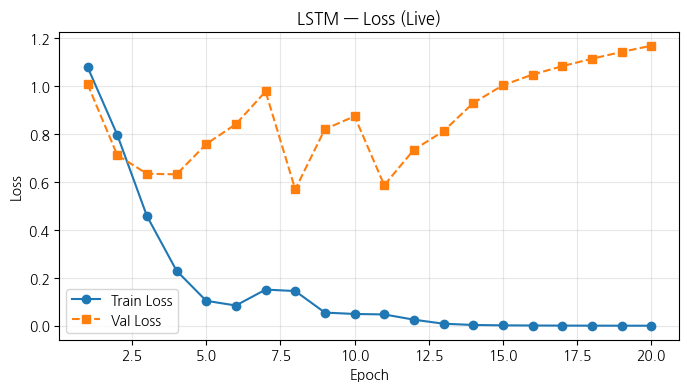


[결과] LSTM 테스트 정확도: 0.8062
------------------------------------------------------------
[LSTM 학습 후] 학습된 문장 벡터 추출...
[저장] fig04_lstm_after.png


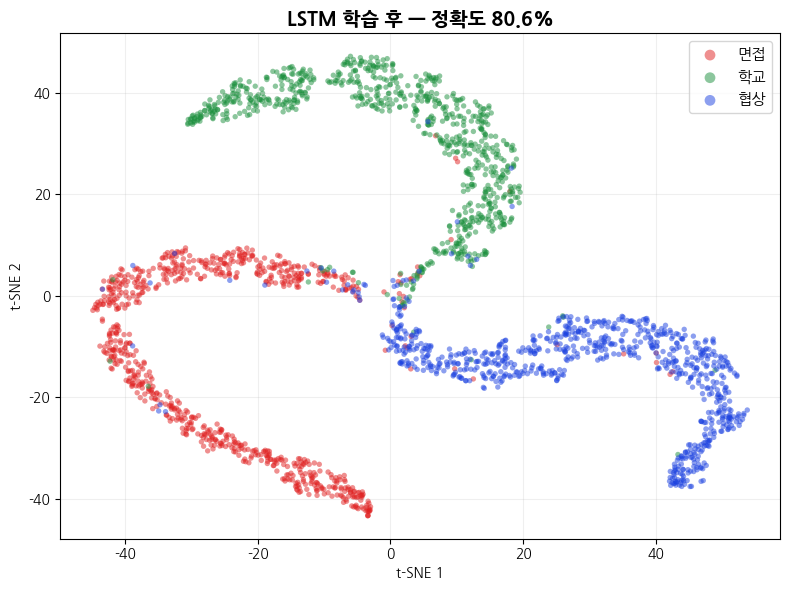

In [17]:
# =============================================================
# Part E · LSTM — 학습 전 시각화
# =============================================================

model_lstm = build_lstm()
model_lstm.summary()
print("-" * 60)

print("[LSTM 학습 전] 랜덤 초기화 상태의 문장 벡터 추출...")
vectors_lstm_before = extract_sentence_vectors(model_lstm, X, "lstm")

plot_tsne(
    vectors_lstm_before, y, class_names,
    title="LSTM 학습 전 — 랜덤 초기화",
    save_path="fig04_lstm_before.png"
)


# =============================================================
# Part F · LSTM — 모델 학습
# =============================================================

EPOCHS     = 20
BATCH_SIZE = 128

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[LiveLossCallback(model_name="LSTM")],
    verbose=0
)

loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f"\n[결과] LSTM 테스트 정확도: {acc_lstm:.4f}")
print("-" * 60)


# =============================================================
# Part G · LSTM — 학습 후 시각화
# =============================================================

print("[LSTM 학습 후] 학습된 문장 벡터 추출...")
vectors_lstm_after = extract_sentence_vectors(model_lstm, X, "lstm")

plot_tsne(
    vectors_lstm_after, y, class_names,
    title=f"LSTM 학습 후 — 정확도 {acc_lstm:.1%}",
    save_path="fig04_lstm_after.png"
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 32, 64)         │     2,048,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,883 (8.10 MB)

 Trainable params: 2,122,883 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

------------------------------------------------------------
[GRU 학습 전] 랜덤 초기화 상태의 문장 벡터 추출...
[저장] fig04_gru_before.png


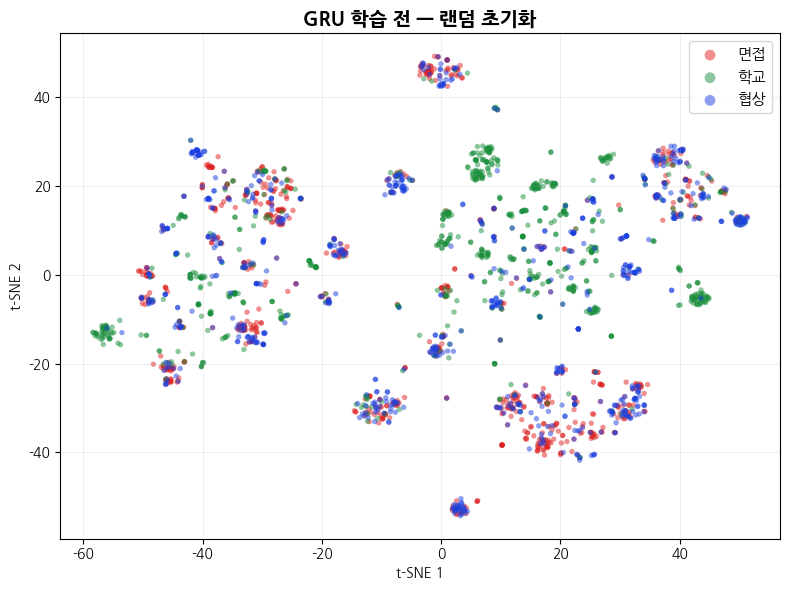

In [18]:
# =============================================================
# Part H · GRU — 학습 전 시각화
# =============================================================

model_gru = build_gru()
model_gru.summary()
print("-" * 60)

print("[GRU 학습 전] 랜덤 초기화 상태의 문장 벡터 추출...")
vectors_gru_before = extract_sentence_vectors(model_gru, X, "gru")

plot_tsne(
    vectors_gru_before, y, class_names,
    title="GRU 학습 전 — 랜덤 초기화",
    save_path="fig04_gru_before.png"
)

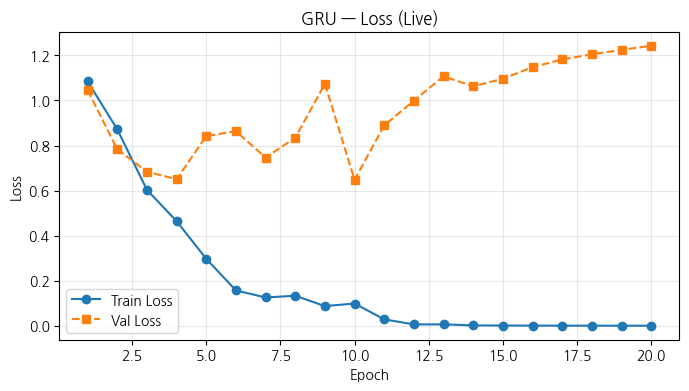


[결과] GRU 테스트 정확도: 0.7875
------------------------------------------------------------


In [19]:
# =============================================================
# Part I · GRU — 모델 학습
# =============================================================

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[LiveLossCallback(model_name="GRU")],
    verbose=0
)

loss_gru, acc_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f"\n[결과] GRU 테스트 정확도: {acc_gru:.4f}")
print("-" * 60)

[GRU 학습 후] 학습된 문장 벡터 추출...
[저장] fig04_gru_after.png


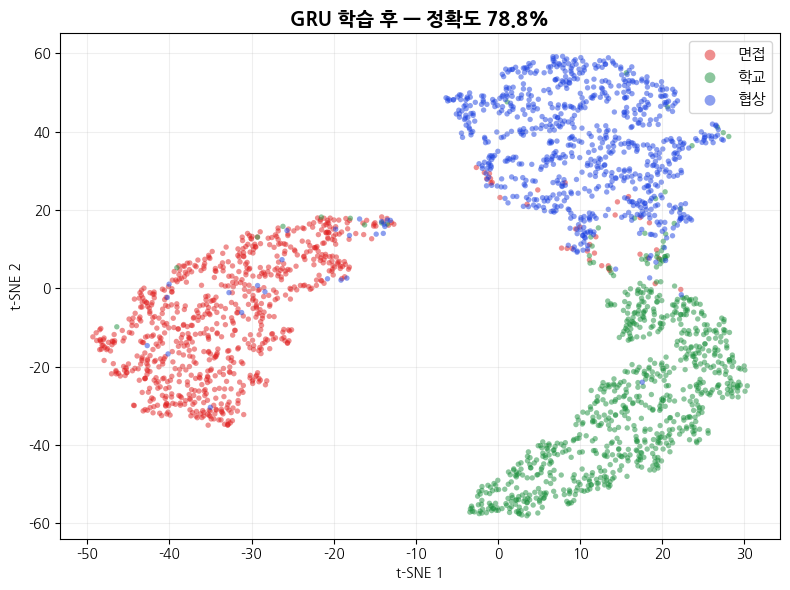

In [20]:
# =============================================================
# Part J · GRU — 학습 후 시각화
# =============================================================

print("[GRU 학습 후] 학습된 문장 벡터 추출...")
vectors_gru_after = extract_sentence_vectors(model_gru, X, "gru")

plot_tsne(
    vectors_gru_after, y, class_names,
    title=f"GRU 학습 후 — 정확도 {acc_gru:.1%}",
    save_path="fig04_gru_after.png"
)

[저장] fig04_training_curve_compare.png


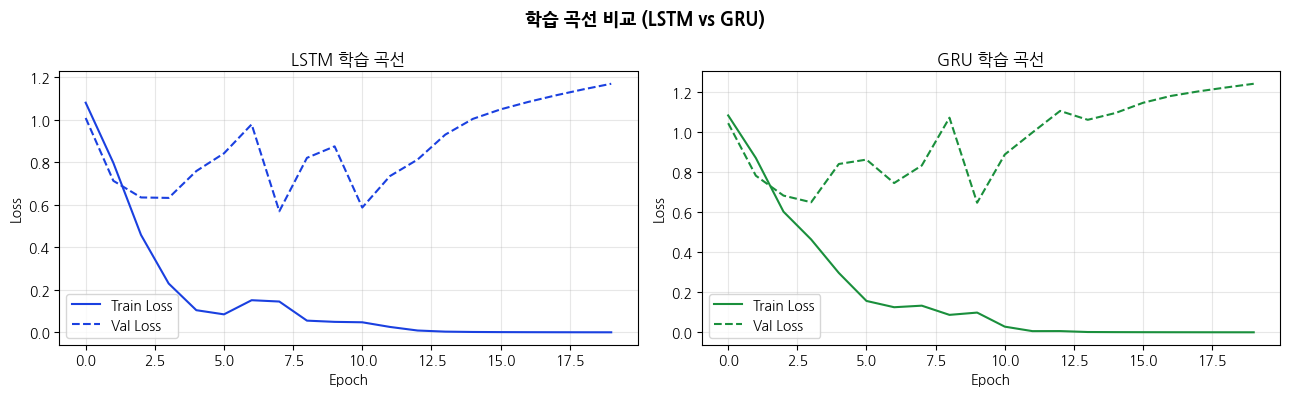


  LSTM 테스트 정확도 : 0.8062 (80.6%)
  GRU  테스트 정확도 : 0.7875 (78.8%)


In [21]:
# =============================================================
# Part K · LSTM vs GRU 정확도 비교
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, hist, label, color in zip(
    axes,
    [history_lstm, history_gru],
    ["LSTM", "GRU"],
    ["#1A40E0", "#1A8F3C"]
):
    ax.plot(hist.history["loss"],     color=color, linestyle="-",  label="Train Loss")
    ax.plot(hist.history["val_loss"], color=color, linestyle="--", label="Val Loss")
    ax.set_title(f"{label} 학습 곡선")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("학습 곡선 비교 (LSTM vs GRU)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig04_training_curve_compare.png", dpi=150, bbox_inches="tight")
print("[저장] fig04_training_curve_compare.png")
plt.show()

print("\n" + "=" * 40)
print(f"  LSTM 테스트 정확도 : {acc_lstm:.4f} ({acc_lstm:.1%})")
print(f"  GRU  테스트 정확도 : {acc_gru:.4f} ({acc_gru:.1%})")
print("=" * 40)